In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [80]:
product_df = pd.read_csv('C:/Users/Playdata/workspace/05_machine_learning/08_clustering/data/pricerunner_aggregate.csv')
product_df.head()

,Product ID,Product Title,Merchant ID,Cluster ID,Cluster Label,Category ID,Category Label
0,1,apple iphone 8 plus 64gb silver,1,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
1,2,apple iphone 8 plus 64 gb spacegrau,2,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
3,4,apple iphone 8 plus 64gb space grey,4,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones


In [81]:
product_df.describe()
print(product_df.isnull().sum())
product_df = product_df.dropna()

Product ID         0
Product Title      0
 Merchant ID       0
 Cluster ID        0
 Cluster Label     0
 Category ID       0
 Category Label    0
dtype: int64


In [82]:
def clean(text):
    cleaned = ''.join(char for char in text.lower() if char.isalnum() or char.isspace())
    return cleaned

product_df['clean_title'] = product_df['Product Title'].apply(clean)

product_df


,Product ID,Product Title,Merchant ID,Cluster ID,Cluster Label,Category ID,Category Label,clean_title
0,1,apple iphone 8 plus 64gb silver,1,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones,apple iphone 8 plus 64gb silver
1,2,apple iphone 8 plus 64 gb spacegrau,2,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones,apple iphone 8 plus 64 gb spacegrau
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones,apple mq8n2ba iphone 8 plus 64gb 55 12mp sim f...
3,4,apple iphone 8 plus 64gb space grey,4,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones,apple iphone 8 plus 64gb space grey
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones,apple iphone 8 plus gold 55 64gb 4g unlocked s...
...,...,...,...,...,...,...,...,...
35306,47350,smeg fab28 60cm retro style right hand hinge f...,59,47517,Smeg FAB28 Cream,2623,Fridges,smeg fab28 60cm retro style right hand hinge f...
35307,47351,smeg fab28 60cm retro style left hand hinge fr...,59,47518,Smeg FAB28 Red,2623,Fridges,smeg fab28 60cm retro style left hand hinge fr...
35308,47352,smeg fab28 60cm retro style left hand hinge fr...,59,47519,Smeg FAB28 Pink,2623,Fridges,smeg fab28 60cm retro style left hand hinge fr...
35309,47355,candy 60cm built under larder fridge cru160nek,125,47524,Candy CRU16.0,2623,Fridges,candy 60cm built under larder fridge cru160nek


In [83]:
from sklearn.feature_extraction.text import TfidfVectorizer

tft_transformer = TfidfVectorizer(stop_words='english',max_features=1000)

product_name_mat = tft_transformer.fit_transform(product_df['clean_title'])

print(product_name_mat.shape)

(35311, 1000)


Cluster k=2 -> Silhouette Score: 0.0216
Cluster k=3 -> Silhouette Score: 0.0250
Cluster k=4 -> Silhouette Score: 0.0316
Cluster k=5 -> Silhouette Score: 0.0403
Cluster k=6 -> Silhouette Score: 0.0452
Cluster k=7 -> Silhouette Score: 0.0530
Cluster k=8 -> Silhouette Score: 0.0534
Cluster k=9 -> Silhouette Score: 0.0593
Cluster k=10 -> Silhouette Score: 0.0634


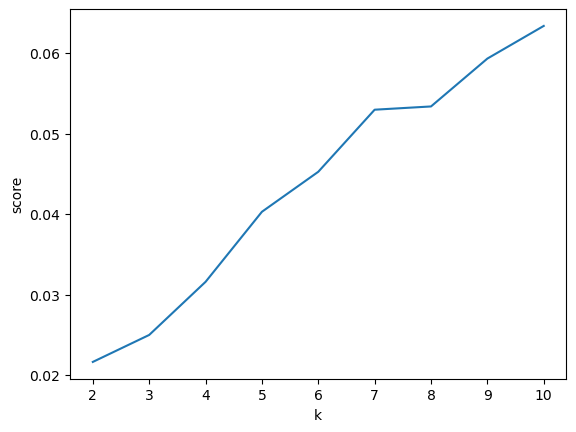

In [ ]:
from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

sil_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(product_name_mat)
    score = silhouette_score(product_name_mat, labels) 
    sil_scores.append(score)
    print(f"Cluster k={k} -> Silhouette Score: {score:.4f}")

plt.plot(range(2,11),sil_scores)
plt.xlabel('k')
plt.ylabel('score')
plt.show()  

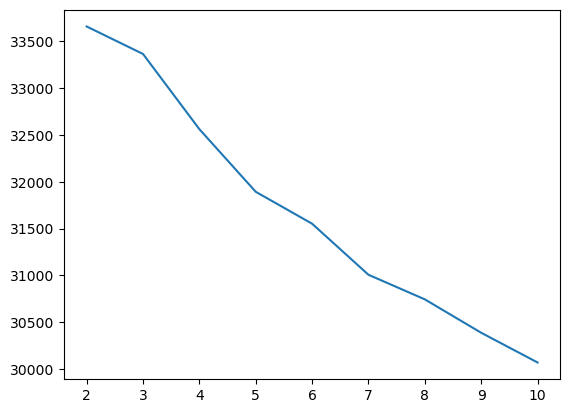

In [85]:
inertia = []

for k in range (2,11):
    kmeans = KMeans(n_clusters=k,random_state=42)
    labels = kmeans.fit_predict(product_name_mat)
    inertia.append(kmeans.inertia_)

plt.plot(range(2,11),inertia)
plt.show()

In [99]:
kmeans = KMeans(n_clusters=10,random_state=42)
labels = kmeans.fit_predict(product_name_mat)

product_df['cluster'] = labels
product_df

,Product ID,Product Title,Merchant ID,Cluster ID,Cluster Label,Category ID,Category Label,clean_title,cluster
0,1,apple iphone 8 plus 64gb silver,1,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones,apple iphone 8 plus 64gb silver,1
1,2,apple iphone 8 plus 64 gb spacegrau,2,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones,apple iphone 8 plus 64 gb spacegrau,1
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones,apple mq8n2ba iphone 8 plus 64gb 55 12mp sim f...,1
3,4,apple iphone 8 plus 64gb space grey,4,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones,apple iphone 8 plus 64gb space grey,1
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones,apple iphone 8 plus gold 55 64gb 4g unlocked s...,1
...,...,...,...,...,...,...,...,...,...
35306,47350,smeg fab28 60cm retro style right hand hinge f...,59,47517,Smeg FAB28 Cream,2623,Fridges,smeg fab28 60cm retro style right hand hinge f...,1
35307,47351,smeg fab28 60cm retro style left hand hinge fr...,59,47518,Smeg FAB28 Red,2623,Fridges,smeg fab28 60cm retro style left hand hinge fr...,1
35308,47352,smeg fab28 60cm retro style left hand hinge fr...,59,47519,Smeg FAB28 Pink,2623,Fridges,smeg fab28 60cm retro style left hand hinge fr...,1
35309,47355,candy 60cm built under larder fridge cru160nek,125,47524,Candy CRU16.0,2623,Fridges,candy 60cm built under larder fridge cru160nek,3


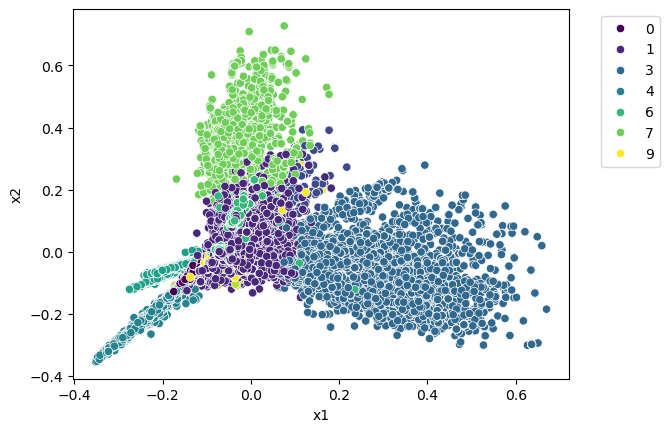

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
product_pca = pca.fit_transform(product_name_mat)

pca_df = pd.DataFrame(product_pca, columns=['x1', 'x2'])
pca_df['cluster'] = product_df['cluster'].values

sns.scatterplot(data=pca_df, x='x1', y='x2', hue='cluster', palette='viridis')
plt.show()